# Steam Trajectory — Data Exploration & Cohort Selection

Loading the fronkongames/steam-games-dataset **JSON** export (switched from CSV after validation revealed row-level misalignment — see notes in `kaggle_loader.py`). This notebook validates the data, then works through *why* the cohort is filtered the way it is before actually selecting it — each filter criterion below was motivated by something concrete found in the data, not decided upfront.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("/Users/pmacias/Dropbox/steamproject")
print(os.getcwd())

/Users/pmacias/Dropbox/steamproject


In [2]:
from steam_trajectory.ingest.kaggle_loader import KaggleLoader

loader = KaggleLoader("data/raw/games.json")
df = loader.df
print(df.shape)
df.head()

(135043, 11)


,AppID,Name,Release date,Developers,Publishers,Price,total_reviews,review_score_percent,Genres,Peak CCU,Estimated owners
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",NaN,NaN,0.00,0,NaN,NaN,0,0 - 0
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",minori,MangaGamer,5.24,255,98.823529,Adventure,0,0 - 20000
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",Somer Games,8floor,4.99,24,87.500000,Casual,0,0 - 20000
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",유진게임즈,유진게임즈,8.99,0,NaN,"Casual, Indie, Simulation",1,0 - 20000
4,3631080,Maze Quest VR,"Apr 24, 2025",Reality Expanded LLC,Reality Expanded LLC,4.99,0,NaN,"Action, Early Access",0,0 - 20000


## Validation
Confirming the JSON loaded cleanly before trusting `select_cohort()`'s output. No CSV-style alignment issues are possible here (JSON fields are explicitly keyed, not positional), but worth still checking for data-quality issues (missing dates, bad AppIDs, etc.) independent of the format itself.

In [3]:
import pandas as pd

# 1. Do release dates parse cleanly?
release_dates = pd.to_datetime(df["Release date"], errors="coerce")
print("Unparseable release dates:", release_dates.isna().sum(), "of", len(df))

Unparseable release dates: 0 of 135043


In [4]:
# 2. Is AppID unique and always an integer? Our whole schema's
# primary key depends on this being true.
print("Duplicate AppIDs:", df["AppID"].duplicated().sum())
print("AppID dtype:", df["AppID"].dtype)

Duplicate AppIDs: 0
AppID dtype: int64


In [5]:
# 3. Is Price always numeric and non-negative?
print("Price dtype:", df["Price"].dtype)
print("Negative prices:", (df["Price"] < 0).sum())
print("Missing prices:", df["Price"].isna().sum())

Price dtype: float64
Negative prices: 0
Missing prices: 0


In [6]:
# 4. Spot-check: do name/date/price/genre all look like they
# plausibly belong to the same game, across a random sample?
df.sample(10, random_state=1)[["Name", "Release date", "Price", "Genres"]]

,Name,Release date,Price,Genres
109723,Blacksmith Simulator,"Nov 28, 2025",5.99,"Adventure, Casual, Indie, Simulation"
26780,"Ethyrial, Echoes of Yore Playtest","Jan 24, 2025",0.00,NaN
78923,ETERNAL EXILE: BENEATH THE DARKNESS,"Aug 20, 2025",15.99,"Action, Indie"
51423,Where is my car? Playtest,"Sep 30, 2025",0.00,NaN
125316,PengPong: Prologue,"Feb 20, 2026",0.00,"Action, Casual, Indie, Free To Play"
88912,Stagehand Survival Simulator Playtest,"Feb 13, 2023",0.00,NaN
90366,Smash and Bash Monsters: Prologue,"Jul 22, 2024",0.00,"Action, Casual, Indie, RPG, Free To Play"
127770,Chronicles: Immortal Sect,"Mar 28, 2026",0.00,"Adventure, Massively Multiplayer, RPG, Free To..."
45862,Video World,"Jan 21, 2021",0.00,Indie
33603,Prince Of Wallachia,"Apr 28, 2021",0.59,"Action, Adventure, Indie"


In [7]:
# 5. total_reviews / review_score_percent sanity check
print(df[["total_reviews", "review_score_percent"]].describe())

       total_reviews  review_score_percent
count   1.350430e+05          82979.000000
mean    1.102677e+03             75.824456
std     3.110025e+04             23.868394
min     0.000000e+00              0.000000
25%     0.000000e+00             64.964021
50%     4.000000e+00             81.818182
75%     3.900000e+01             94.444444
max     8.815087e+06            100.000000


## Why we filter beyond release date and review count

The obvious first cut is "2019-2022 releases with 500+ reviews" — but two problems with that alone turned up once we actually looked at what it selects. Both are investigated below, and both directly motivate an additional filter criterion used in the final `select_cohort()` call.

First, build the base pool (release window + review count only, nothing else) that both investigations below start from:

In [8]:
release_dates = pd.to_datetime(loader.df["Release date"], errors="coerce")
mask = (
    (release_dates >= "2019-01-01") & (release_dates <= "2022-12-31")
    & (loader.df["total_reviews"] >= 500)
)
pre_filter_pool = loader.df[mask]
print(f"{len(pre_filter_pool)} games qualify on release date + review count alone")

3419 games qualify on release date + review count alone


### Problem 1: non-game software
Steam sells non-game software (art tools, VR utilities, RPG-making tools, etc.) through the same storefront and review system. A release-date + review-count filter alone let a handful of these slip in — confirmed by finding titles like *Pixel Studio*, *YoloMouse*, *RPG Maker MZ*, and *LIV* in an early cohort draw, none of which carry any traditional gameplay genre.

The fix combines two checks (see `KaggleLoader._REAL_GAME_GENRES` / `_NON_GAME_CATEGORIES`):
1. **Whitelist** — must have at least one gameplay-adjacent genre
2. **Blacklist** — must not carry a known non-game category

Both are needed: some tools carry a genre *also* used by real games (e.g. "Early Access" is a dev-status label, not gameplay — confirmed by *ScreenPlay* and *XSOverlay*, both non-game VR/utility software tagged "Early Access" alongside "Utilities"). A pure whitelist check alone doesn't look at "Utilities" at all if "Early Access" is present, so the blacklist catches what the whitelist misses.

Worth noting: "Casual", "Indie", and "Free To Play" were initially treated as ambiguous status labels and left off the whitelist, but checking against real data showed this wrongly dropped ~190 genuine games (e.g. *inbento*, *Puyo Puyo Champions*, *Shady Part of Me*) whose only genre tag was one of these three — so all three were added back in. "Early Access" alone stays excluded (confirmed by *Easy Pose*, a non-game posing tool tagged only "Early Access").

In [9]:
def is_real_game(genres_str):
    if pd.isna(genres_str):
        return False
    game_genres = {g.strip() for g in str(genres_str).split(",")}
    has_gameplay_genre = len(game_genres & KaggleLoader._REAL_GAME_GENRES) > 0
    has_non_game_tag = len(game_genres & KaggleLoader._NON_GAME_CATEGORIES) > 0
    return has_gameplay_genre and not has_non_game_tag

dropped = pre_filter_pool[~pre_filter_pool["Genres"].apply(is_real_game)]
print(f"{len(dropped)} games dropped out of {len(pre_filter_pool)} qualifying")

# Specifically isolate ones dropped ONLY because they lack a gameplay
# genre, not because they carry a giveaway non-game tag — these are
# the real, quantifiable false-negative risk
lacks_gameplay_only = dropped[dropped["Genres"].apply(
    lambda g: not pd.isna(g) and
    len(set(str(g).split(", ")) & KaggleLoader._NON_GAME_CATEGORIES) == 0
)]
print(f"Of those, {len(lacks_gameplay_only)} have no obvious non-game tag at all")
lacks_gameplay_only[["Name", "Genres"]].head(20)

46 games dropped out of 3419 qualifying
Of those, 2 have no obvious non-game tag at all


,Name,Genres
3360,Easy Pose,Early Access
81382,Intruder,Early Access


### Problem 2: review count doesn't guarantee concurrent engagement
The trajectory plots in `02_data_visualization.ipynb` kept surfacing games with a lifetime peak of under 100 concurrent players, despite thousands of reviews (e.g. *Eastshade* — a well-reviewed, commercially successful single-player game people finish once and never reopen). Review count reflects total unit sales over time, not how many people were ever playing *simultaneously* — so it doesn't select for sustained/concurrent engagement at all, which is what this whole project is trying to model.

`Peak CCU` (Steam's own reported peak concurrent players) is available in the metadata, before any scraping — so we can pre-filter on it directly.

count      3419.000000
mean        346.983328
std        3139.219027
min           0.000000
25%           1.500000
50%           7.000000
75%          42.500000
max      124262.000000
Name: Peak CCU, dtype: float64


<Axes: title={'center': 'Peak CCU (metadata) — release+review-qualifying pool'}, ylabel='Frequency'>

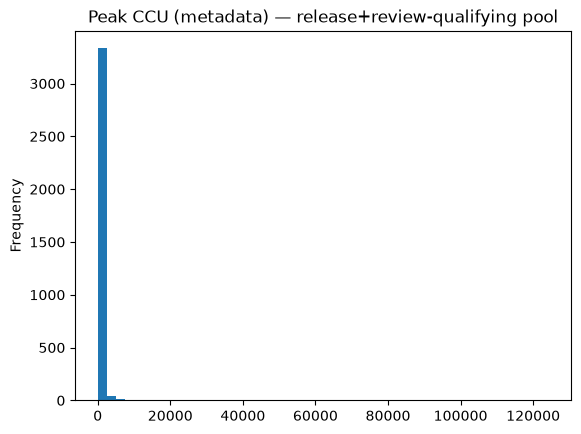

In [10]:
print(pre_filter_pool["Peak CCU"].describe())
pre_filter_pool["Peak CCU"].plot(kind="hist", bins=50, title="Peak CCU (metadata) — release+review-qualifying pool")

In [11]:
for pct in [50, 75, 90, 95, 99]:
    print(f"{pct}th percentile: {pre_filter_pool['Peak CCU'].quantile(pct/100):.1f}")

print()
for threshold in [50, 100, 200, 500, 1000]:
    n = (pre_filter_pool["Peak CCU"] >= threshold).sum()
    print(f"Peak CCU >= {threshold}: {n} games ({n/len(pre_filter_pool)*100:.1f}%)")

50th percentile: 7.0
75th percentile: 42.5
90th percentile: 257.2
95th percentile: 907.7
99th percentile: 6306.6

Peak CCU >= 50: 788 games (23.0%)
Peak CCU >= 100: 568 games (16.6%)
Peak CCU >= 200: 400 games (11.7%)
Peak CCU >= 500: 237 games (6.9%)
Peak CCU >= 1000: 154 games (4.5%)


**Decision: `min_peak_ccu=200`.** Median Peak CCU across the qualifying pool is just 7 — most games never had more than a trickle of simultaneous players even at their absolute best. A threshold of 200 sits well above the median and 75th percentile (42.5), meaningfully selecting for games that achieved real concurrent engagement, while still leaving ~400 candidates — enough headroom above our target cohort size once genre filtering and SteamCharts scraping failures (typically 15-25%) are accounted for. Higher thresholds (500, 1000) leave too thin a pool once those losses stack.

This is a deliberate, flux-limited sample, not a bug: the resulting cohort characterizes trajectory shape for games that have *already* demonstrated meaningful sustained concurrent engagement, rather than attempting to model the (much noisier) full population of commercially-successful-but-low-CCU releases.

## Cohort selection
With both criteria motivated above, select the actual research cohort: 2019-2022 releases, 500+ reviews, Peak CCU >= 200, real games only (genre-filtered). No further sampling — take the full qualifying pool (~400 games) and let natural attrition (genre filter already applied here, then scraping failures in `01_scrape_and_load.ipynb`) determine the final cohort size.

In [12]:
candidates = loader.select_cohort(
    release_start="2019-01-01",
    release_end="2022-12-31",
    min_reviews=500,
    min_peak_ccu=200,
    sample_size=None,
)
print(candidates.shape)
candidates[["AppID", "Name", "Release date", "total_reviews", "Peak CCU"]].head(10)

(382, 11)


,AppID,Name,Release date,total_reviews,Peak CCU
0,1517290,Battlefield™ 2042,"Nov 19, 2021",297774,2774
1,1088850,Marvel's Guardians of the Galaxy,"Oct 26, 2021",39158,219
2,1296830,暖雪 Warm Snow,"Jan 18, 2022",37007,516
3,1170950,Mortal Online 2,"Jan 25, 2022",12943,440
4,1353300,Idle Slayer,"Dec 21, 2020",8767,1300
5,326460,ShellShock Live,"May 22, 2020",34893,297
6,1384160,GUILTY GEAR -STRIVE-,"Jun 11, 2021",59382,2463
7,1850570,DEATH STRANDING DIRECTOR'S CUT,"Mar 30, 2022",39516,1604
8,1097150,Fall Guys,"Aug 3, 2020",473743,664
9,244850,Space Engineers,"Feb 28, 2019",132347,4201


## Quantifying the bias introduced by the Peak CCU cut
We know `min_peak_ccu=200` introduces selection bias relative to the full review-qualifying population — that's the point, but worth quantifying rather than just asserting. Compare `total_reviews` between the CCU-filtered cohort and the genre-filtered-but-NOT-CCU-filtered pool it was drawn from, holding the genre filter constant so this isolates the effect of the CCU cut specifically.

In [13]:
full_qualifying_pool = loader.select_cohort(
    release_start="2019-01-01",
    release_end="2022-12-31",
    min_reviews=500,
    sample_size=None,  # no min_peak_ccu, no sampling — genre-filtered but CCU-unfiltered
)
print("Full qualifying pool size (genre-filtered, no CCU cut):", len(full_qualifying_pool))
print(full_qualifying_pool["total_reviews"].describe())
print()
print("Our CCU-filtered cohort:")
print(candidates["total_reviews"].describe())

Full qualifying pool size (genre-filtered, no CCU cut): 3373
count    3.373000e+03
mean     1.139381e+04
std      4.885610e+04
min      5.000000e+02
25%      8.720000e+02
50%      1.789000e+03
75%      5.245000e+03
max      1.056677e+06
Name: total_reviews, dtype: float64

Our CCU-filtered cohort:
count    3.820000e+02
mean     7.264753e+04
std      1.284964e+05
min      7.080000e+02
25%      1.262700e+04
50%      2.947000e+04
75%      8.051225e+04
max      1.056677e+06
Name: total_reviews, dtype: float64


## Save the candidate list
Frozen for `01_scrape_and_load.ipynb` to read — this is the *candidate* pool (pre-scraping); the actual final cohort gets frozen separately in notebook 01 after scraping failures are dropped.

In [14]:
candidates.to_csv("candidate_appids.csv", index=False)
print(f"Saved {len(candidates)} candidates to candidate_appids.csv")

Saved 382 candidates to candidate_appids.csv
